<a href="https://colab.research.google.com/github/xBhoomi-AR/Fantasy-XI/blob/Bhoomi/PPO_Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install gymnasium stable-baselines3 yfinance ta matplotlib pandas numpy

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

In [ ]:
stocks = [
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "GOOG",   # Google
    "AMZN",   # Amazon
    "META",   # Meta
    "NVDA",   # Nvidia
    "TSLA",   # Tesla
    "JPM",    # JPMorgan
    "KO",     # Coca-Cola
    "PEP"     # PepsiCo
]

start_date = "2018-01-01"
end_date = "2024-12-31"

In [ ]:
all_data = []

for ticker in stocks:

    print(f"Downloading {ticker}...")

    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )
    data.columns = data.columns.get_level_values(0)

    data.reset_index(inplace=True)

    data["ticker"] = ticker

    data = data[
        [
            "Date",
            "ticker",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ]

    all_data.append(data)

raw_data = pd.concat(all_data, ignore_index=True)

raw_data.sort_values(
    by=["ticker", "Date"],
    inplace=True
)

raw_data.reset_index(drop=True, inplace=True)
raw_data.info()
display(raw_data.head(20))
print("=" * 60)
print("Data Download Summary")
print("=" * 60)

print(f"Total rows downloaded : {len(raw_data)}")
print(f"Number of stocks      : {raw_data['ticker'].nunique()}")

print("\nRows per stock:\n")
print(raw_data["ticker"].value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17600 entries, 0 to 17599
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    17600 non-null  datetime64[ns]
 1   ticker  17600 non-null  object        
 2   Open    17600 non-null  float64       
 3   High    17600 non-null  float64       
 4   Low     17600 non-null  float64       
 5   Close   17600 non-null  float64       
 6   Volume  17600 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 962.6+ KB


Price,Date,ticker,Open,High,Low,Close,Volume
0,2018-01-02,AAPL,39.776186,40.276427,39.565802,40.267075,102223600
1,2018-01-03,AAPL,40.330195,40.802386,40.196955,40.260067,118071600
2,2018-01-04,AAPL,40.332521,40.549917,40.224995,40.447063,89738400
3,2018-01-05,AAPL,40.542912,40.994063,40.451747,40.907574,94640000
4,2018-01-08,AAPL,40.755623,41.050156,40.657442,40.755623,82271200
5,2018-01-09,AAPL,40.802373,40.921588,40.535890,40.750946,86336000
6,2018-01-10,AAPL,40.477472,40.743955,40.440070,40.741615,95839600
7,2018-01-11,AAPL,40.811737,41.022121,40.788363,40.973030,74670800
8,2018-01-12,AAPL,41.183402,41.459238,41.059511,41.396122,101672400
9,2018-01-16,AAPL,41.585473,41.933773,41.174060,41.185749,118263600


Data Download Summary
Total rows downloaded : 17600
Number of stocks      : 10

Rows per stock:

ticker
AAPL    1760
AMZN    1760
GOOG    1760
JPM     1760
KO      1760
META    1760
MSFT    1760
NVDA    1760
PEP     1760
TSLA    1760
Name: count, dtype: int64


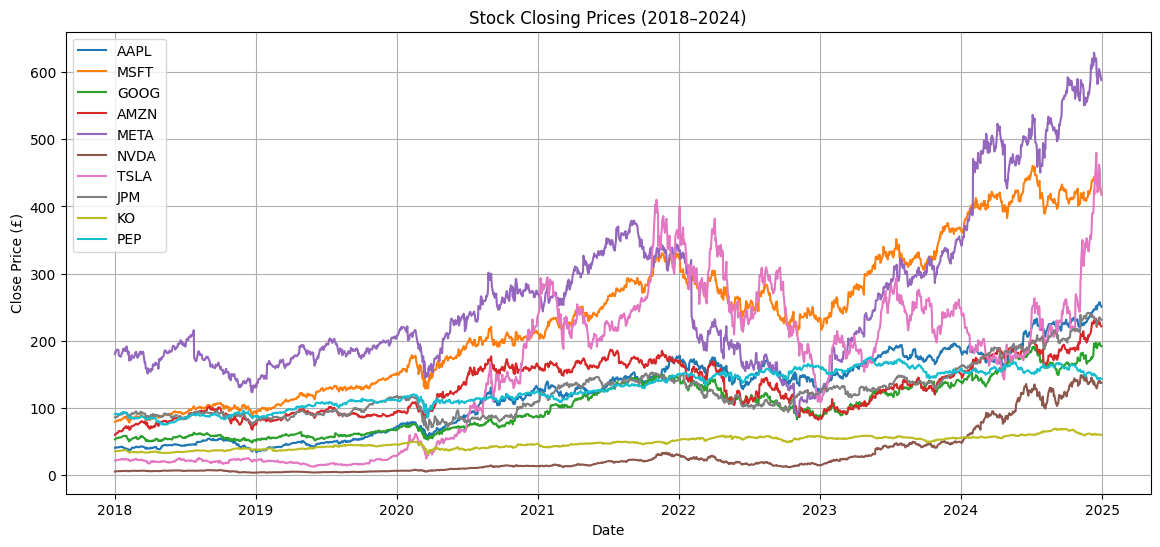

In [ ]:
plt.figure(figsize=(14,6))

for ticker in stocks:
    stock = raw_data[raw_data["ticker"] == ticker]

    plt.plot(
        stock["Date"],
        stock["Close"],
        label=ticker
    )

plt.title("Stock Closing Prices (2018–2024)")
plt.xlabel("Date")
plt.ylabel("Close Price (£)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
raw_data = raw_data.sort_values(
    by=["ticker", "Date"]
).reset_index(drop=True)



In [ ]:
raw_data["daily_return"] = (
    raw_data
    .groupby("ticker")["Close"]
    .pct_change()
)

raw_data["volatility20"] = (
    raw_data
    .groupby("ticker")["daily_return"]
    .transform(
        lambda x: x.rolling(20).std()
    )
)
raw_data["price_momentum"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x / x.shift(20)
    )
)



In [ ]:
raw_data["sma20"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(20).mean()
    )
)

raw_data["sma50"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(50).mean()
    )
)

raw_data["price_sma20_ratio"] = (
    raw_data["Close"] /
    raw_data["sma20"]
)

raw_data["price_sma50_ratio"] = (
    raw_data["Close"] /
    raw_data["sma50"]
)

In [ ]:
raw_data["sma10"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(10).mean()
    )
)

raw_data["sma30"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.rolling(30).mean()
    )
)

raw_data["sma_crossover"] = (
    raw_data["sma10"] /
    raw_data["sma30"]
)

In [ ]:
raw_data["ema12"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(
        lambda x: x.ewm(span=12, adjust=False).mean()
    )
)

raw_data["price_ema12_ratio"] = (
    raw_data["Close"] /
    raw_data["ema12"]
)



In [ ]:
def compute_rsi(close):

    return ta.momentum.RSIIndicator(
        close=close,
        window=14
    ).rsi()


raw_data["rsi14"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(compute_rsi)
)

In [ ]:
def compute_macd(close):

    indicator = ta.trend.MACD(close)

    return indicator.macd()


def compute_macd_signal(close):

    indicator = ta.trend.MACD(close)

    return indicator.macd_signal()


raw_data["macd"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(compute_macd)
)

raw_data["macd_signal"] = (
    raw_data
    .groupby("ticker")["Close"]
    .transform(compute_macd_signal)
)

In [ ]:
raw_data["high_low_range"] = (
    raw_data["High"] -
    raw_data["Low"]
) / raw_data["Close"]

In [ ]:
raw_data["volume_sma20"] = (
    raw_data
    .groupby("ticker")["Volume"]
    .transform(
        lambda x: x.rolling(20).mean()
    )
)

raw_data["volume_ratio"] = (
    raw_data["Volume"] /
    raw_data["volume_sma20"]
)

In [ ]:
feature_data = (
    raw_data
    .dropna()
    .reset_index(drop=True)
)

In [ ]:
print(feature_data.info())

feature_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17110 entries, 0 to 17109
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               17110 non-null  datetime64[ns]
 1   ticker             17110 non-null  object        
 2   Open               17110 non-null  float64       
 3   High               17110 non-null  float64       
 4   Low                17110 non-null  float64       
 5   Close              17110 non-null  float64       
 6   Volume             17110 non-null  int64         
 7   daily_return       17110 non-null  float64       
 8   volatility20       17110 non-null  float64       
 9   price_momentum     17110 non-null  float64       
 10  sma20              17110 non-null  float64       
 11  sma50              17110 non-null  float64       
 12  price_sma20_ratio  17110 non-null  float64       
 13  price_sma50_ratio  17110 non-null  float64       
 14  sma10 

Price,Date,ticker,Open,High,Low,Close,Volume,daily_return,volatility20,price_momentum,...,sma30,sma_crossover,ema12,price_ema12_ratio,rsi14,macd,macd_signal,high_low_range,volume_sma20,volume_ratio
0,2018-03-14,AAPL,42.323021,42.369962,41.733895,41.881763,117473600,-0.008502,0.012689,1.085798,...,40.094534,1.040115,41.634809,1.005931,57.985793,0.642079,0.553162,0.015187,140684940.0,0.835012
1,2018-03-15,AAPL,41.895848,42.304246,41.794924,41.931053,90975200,0.001177,0.012249,1.067395,...,40.187635,1.039837,41.680385,1.006014,58.342758,0.618150,0.566160,0.012147,137104720.0,0.663545
2,2018-03-16,AAPL,41.931042,42.041356,41.689290,41.783176,157618800,-0.003527,0.010038,1.029077,...,40.273079,1.038686,41.696199,1.002086,56.783981,0.580561,0.569040,0.008426,134756220.0,1.169659
3,2018-03-19,AAPL,41.618884,41.654089,40.759843,41.144768,133787200,-0.015279,0.010677,1.016644,...,40.393969,1.034694,41.611363,0.988787,50.509807,0.493567,0.553946,0.021734,133410360.0,1.002825
4,2018-03-20,AAPL,41.130680,41.496828,41.060266,41.130680,78597600,-0.000342,0.010635,1.019726,...,40.545634,1.029996,41.537412,0.990208,50.377528,0.418662,0.526889,0.010614,130554140.0,0.602031


In [ ]:
train_data.to_csv(
    "train_data.csv",
    index=False
)

validation_data.to_csv(
    "validation_data.csv",
    index=False
)

test_data.to_csv(
    "test_data.csv",
    index=False
)

feature_data = {
    ticker: train_data[train_data["ticker"] == ticker].reset_index(drop=True)
    for ticker in stocks
}


In [ ]:
%%writefile portfolio_env.py
import gymnasium as gym
import numpy as np
import pandas as pd
from gymnasium import spaces


class PortfolioEnv(gym.Env):

    metadata = {"render_modes": ["human"]}

    feature_cols = [
        "daily_return",
        "price_momentum",
        "price_sma20_ratio",
        "price_sma50_ratio",
        "sma_crossover",
        "price_ema12_ratio",
        "rsi14",
        "macd",
        "macd_signal",
        "volatility20",
        "high_low_range",
        "volume_ratio",
    ]

    n_stock_features = len(feature_cols)

    def __init__(
        self,
        feature_data,
        tickers,
        window=20,
        initial_capital=100000,
        transaction_cost=0.001,
        episode_length=252,
    ):

        super().__init__()

        self.tickers = tickers
        self.n_stocks = len(tickers)

        self.window = window
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost
        self.episode_length = episode_length

        self._build_arrays(feature_data)

        # ---------------- Observation Space ----------------

        observation_size = (
            self.window
            * self.n_stocks
            * self.n_stock_features
            + self.n_stocks
            + 1
        )

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(observation_size,),
            dtype=np.float32,
        )

        # ---------------- Action Space ----------------

        self.action_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(self.n_stocks,),
            dtype=np.float32,
        )

    def _build_arrays(self, feature_data):

        print("build arrays called")

        # ---------- Find common trading dates ----------

        common_trading_dates = None

        for ticker in self.tickers:

            stock_data = feature_data[ticker].copy()

            stock_data["Date"] = pd.to_datetime(stock_data["Date"])
            stock_data = stock_data.set_index("Date")

            if common_trading_dates is None:
                common_trading_dates = stock_data.index
            else:
                common_trading_dates = (
                    common_trading_dates.intersection(stock_data.index)
                )

        common_trading_dates = common_trading_dates.sort_values()

        self.trading_dates = common_trading_dates
        self.total_trading_days = len(common_trading_dates)

        # ---------- Create empty arrays ----------

        feature_array = np.zeros(
            (
                self.total_trading_days,
                self.n_stocks,
                self.n_stock_features,
            ),
            dtype=np.float32,
        )

        close_price_array = np.zeros(
            (
                self.total_trading_days,
                self.n_stocks,
            ),
            dtype=np.float32,
        )

        # ---------- Fill arrays ----------

        for stock_index, ticker in enumerate(self.tickers):

            stock_data = feature_data[ticker].copy()

            stock_data["Date"] = pd.to_datetime(stock_data["Date"])
            stock_data = stock_data.set_index("Date")

            stock_data = stock_data.loc[common_trading_dates]

            stock_feature_matrix = (
                stock_data[self.feature_cols]
                .fillna(0.0)
                .to_numpy(dtype=np.float32)
            )

            feature_array[:, stock_index, :] = stock_feature_matrix

            close_price_array[:, stock_index] = (
                stock_data["Close"]
                .to_numpy(dtype=np.float32)
            )

        self.feature_array = feature_array
        self.close_price_array = close_price_array

        print("feature array shape      :", self.feature_array.shape)
        print("close price array shape  :", self.close_price_array.shape)
        print("total trading days       :", self.total_trading_days)


    def reset(self, seed=None, options=None):

      super().reset(seed=seed)

      # Make sure there is enough data for one full episode
      maximum_start_day = (
          self.total_trading_days
          - self.episode_length
          - 1
      )

      if maximum_start_day <= self.window:
          raise ValueError(
              f"Not enough data. Need at least "
              f"{self.window + self.episode_length + 1} trading days, "
              f"got {self.total_trading_days}."
          )

      # Random starting day
      self.start_day = self.np_random.integers(
          self.window,
          maximum_start_day,
      )

      self.current_day = self.start_day

      # Equal-weight portfolio
      self.portfolio_weights = (
          np.ones(
              self.n_stocks,
              dtype=np.float32,
          )
          / self.n_stocks
      )

      self.portfolio_value = self.initial_capital

      self.returns_history = []

      observation = self._get_observation()
      info = self._get_info()

      return observation, info

    def _get_observation(self):

        """
        Build observation vector:

        [historical feature window]
        +
        [current portfolio weights]
        +
        [normalized portfolio value]

        Shape:
        (window × n_stocks × n_features)
        + n_stocks
        + 1
        """

        # Get recent market feature window
        # Shape: (window, n_stocks, n_features)

        feature_window = self.feature_array[
            self.current_day - self.window :
            self.current_day
        ]

        # Flatten market information
        # Shape: window*n_stocks*n_features

        flattened_features = feature_window.flatten()


        # Normalize portfolio value

        normalized_portfolio_value = np.array(
            [
                self.portfolio_value /
                self.initial_capital
            ],
            dtype=np.float32
        )


        # Combine all state information

        observation = np.concatenate(
            [
                flattened_features,
                self.portfolio_weights,
                normalized_portfolio_value,
            ]
        )


        return observation.astype(np.float32)

    def _get_info(self) -> dict:

      info = {
          "portfolio_value": self.portfolio_value,

          "portfolio_weights":
              self.portfolio_weights.copy(),

          "current_day":
              self.current_day,

          "date":
              str(self.trading_dates[self.current_day])
              if self.current_day < self.total_trading_days
              else "end",
      }


      # Evaluation metrics
      if len(self.returns_history) > 1:

          returns_array = np.array(
              self.returns_history
          )


          # Total portfolio return

          info["cumulative_return"] = float(
              self.portfolio_value /
              self.initial_capital
              - 1
          )


          # Annualized Sharpe ratio

          info["sharpe_ratio"] = float(
              (
                  returns_array.mean()
                  /
                  (returns_array.std() + 1e-8)
              )
              * np.sqrt(252)
          )


          # Add later after implementing _max_drawdown()
          # info["max_drawdown"] = float(
          #     self._max_drawdown()
          # )


      return info

    def step(self, action: np.ndarray):

      # ─────────────────────────────────────────
      # 1. Convert action into valid portfolio weights
      # ─────────────────────────────────────────

      action = np.abs(action).astype(np.float32)

      total_weight = action.sum()

      if total_weight < 1e-8:

          new_weights = (
              np.ones(self.n_stocks, dtype=np.float32)
              / self.n_stocks
          )

      else:

          new_weights = action / total_weight



      # ─────────────────────────────────────────
      # 2. Calculate stock returns for this day
      # ─────────────────────────────────────────

      current_prices = self.close_price_array[
          self.current_day
      ]

      next_prices = self.close_price_array[
          self.current_day + 1
      ]


      stock_returns = (
          next_prices - current_prices
      ) / (current_prices + 1e-8)



      # ─────────────────────────────────────────
      # 3. Portfolio return before transaction cost
      # ─────────────────────────────────────────

      portfolio_return = np.dot(
          new_weights,
          stock_returns
      )



      # ─────────────────────────────────────────
      # 4. Transaction cost
      # ─────────────────────────────────────────

      weight_change = np.abs(
          new_weights - self.portfolio_weights
      ).sum()


      transaction_cost = (
          self.transaction_cost *
          weight_change
      )



      # ─────────────────────────────────────────
      # 5. Net return and reward
      # ─────────────────────────────────────────

      net_return = (
          portfolio_return -
          transaction_cost
      )


      reward = float(
          np.log1p(net_return)
      )



      # ─────────────────────────────────────────
      # 6. Update environment state
      # ─────────────────────────────────────────

      self.portfolio_value *= (
          1.0 + net_return
      )


      self.portfolio_weights = new_weights


      self.current_day += 1


      self.returns_history.append(
          net_return
      )



      # ─────────────────────────────────────────
      # 7. Check episode completion
      # ─────────────────────────────────────────

      days_elapsed = (
          self.current_day -
          self.start_day
      )


      terminated = (
          days_elapsed >=
          self.episode_length
      )


      truncated = False



      # ─────────────────────────────────────────
      # 8. Return next state
      # ─────────────────────────────────────────

      observation = self._get_observation()

      info = self._get_info()


      return (
          observation,
          reward,
          terminated,
          truncated,
          info

      )

        # ─────────────────────────────────────────────
    # Evaluation Metrics
    # ─────────────────────────────────────────────

    def _max_drawdown(self) -> float:
        """
        Calculate maximum drawdown of portfolio
        during the current episode.
        """

        if len(self.returns_history) == 0:
            return 0.0


        portfolio_values = (
            self.initial_capital *
            np.cumprod(
                1 + np.array(self.returns_history)
            )
        )


        peak_values = np.maximum.accumulate(
            portfolio_values
        )


        drawdowns = (
            portfolio_values - peak_values
        ) / (peak_values + 1e-8)


        return float(drawdowns.min())



    def get_episode_metrics(self) -> dict:
        """
        Calculate final evaluation metrics
        after an episode finishes.
        """

        if len(self.returns_history) == 0:
            return {}


        returns = np.array(
            self.returns_history
        )


        cumulative_return = (
            self.portfolio_value /
            self.initial_capital
            - 1
        )


        annualized_return = (
            (1 + cumulative_return)
            **
            (252 / len(returns))
            - 1
        )


        volatility = (
            returns.std()
            *
            np.sqrt(252)
        )


        sharpe_ratio = (
            returns.mean()
            /
            (returns.std() + 1e-8)
            *
            np.sqrt(252)
        )


        max_drawdown = self._max_drawdown()


        win_rate = (
            returns > 0
        ).mean()



        return {

            "cumulative_return":
                float(cumulative_return * 100),

            "annualized_return":
                float(annualized_return * 100),

            "volatility":
                float(volatility * 100),

            "sharpe_ratio":
                float(sharpe_ratio),

            "max_drawdown":
                float(max_drawdown * 100),

            "win_rate":
                float(win_rate * 100),

            "final_portfolio_value":
                float(self.portfolio_value),

            "total_steps":
                len(returns)
        }

    def render(self):

      print("Step:", self.current_day)
      print("Portfolio Value:", self.portfolio_value)

      print(
          "Return:",
          (self.portfolio_value / self.initial_capital - 1) * 100,
          "%"
      )

      print(
          "Weights:",
          self.portfolio_weights
      )




Overwriting portfolio_env.py


In [ ]:
# ======================================================
# TRAIN / VALIDATION / TEST SPLIT
# ======================================================

train_data = {}
validation_data = {}
test_data = {}


for ticker, df in feature_data.items():

    df = df.sort_values("Date").reset_index(drop=True)

    train_data[ticker] = df[
        df["Date"] < "2022-01-01"
    ].reset_index(drop=True)


    validation_data[ticker] = df[
        (df["Date"] >= "2022-01-01") &
        (df["Date"] < "2023-07-01")
    ].reset_index(drop=True)


    test_data[ticker] = df[
        df["Date"] >= "2023-07-01"
    ].reset_index(drop=True)



print("=" * 60)
print("DATASET SPLIT SUMMARY")
print("=" * 60)


for ticker in feature_data.keys():

    print(
        ticker,
        "| Train:",
        len(train_data[ticker]),
        "| Val:",
        len(validation_data[ticker]),
        "| Test:",
        len(test_data[ticker])
    )


print("\nRequired minimum days:")
print(window + episode_length + 1)

DATASET SPLIT SUMMARY
AAPL | Train: 959 | Val: 0 | Test: 0
MSFT | Train: 959 | Val: 0 | Test: 0
GOOG | Train: 959 | Val: 0 | Test: 0
AMZN | Train: 959 | Val: 0 | Test: 0
META | Train: 959 | Val: 0 | Test: 0
NVDA | Train: 959 | Val: 0 | Test: 0
TSLA | Train: 959 | Val: 0 | Test: 0
JPM | Train: 959 | Val: 0 | Test: 0
KO | Train: 959 | Val: 0 | Test: 0
PEP | Train: 959 | Val: 0 | Test: 0

Required minimum days:


NameError: name 'window' is not defined

In [ ]:
print(type(feature_data))

<class 'dict'>


In [ ]:
from portfolio_env import PortfolioEnv
from gymnasium.utils.env_checker import check_env


print("Building environment...")


env = PortfolioEnv(
    feature_data=feature_data,
    tickers=stocks,
    window=20,
    initial_capital=10000,
    transaction_cost=0.001,
    episode_length=252
)


print("Running Gymnasium checker...")


check_env(env)

print("Environment check passed!")


print("\nRandom agent test")

print("\n" + "="*60)
print("          PORTFOLIO ENVIRONMENT TEST SUMMARY")
print("="*60)


# Environment details
print("\n[ENVIRONMENT CONFIGURATION]")
print("---------------------------")
print("Number of stocks        :", env.n_stocks)
print("Stocks                  :", env.tickers)
print("Total trading days      :", env.total_trading_days)
print("Lookback window         :", env.window)
print("Episode length          :", env.episode_length)
print("Initial capital         :", env.initial_capital)
print("Transaction cost        :", env.transaction_cost)


# Data summary
print("\n[DATA ARRAYS]")
print("---------------------------")
print(
    "Feature array shape     :",
    env.feature_array.shape
)

print(
    "Close price array shape:",
    env.close_price_array.shape
)

print(
    "Number of features     :",
    env.n_stock_features
)


# Spaces
print("\n[GYM SPACES]")
print("---------------------------")
print(
    "Observation space      :",
    env.observation_space
)

print(
    "Action space           :",
    env.action_space
)


# Episode result
print("\n[RANDOM AGENT TEST]")
print("---------------------------")
print(
    "Observation shape      :",
    obs.shape
)

print(
    "Total reward            :",
    round(total_reward, 4)
)


# Evaluation metrics
print("\n[EPISODE PERFORMANCE METRICS]")
print("---------------------------")

for key, value in metrics.items():

    if isinstance(value, float):
        print(
            f"{key:25s}: {value:.4f}"
        )
    else:
        print(
            f"{key:25s}: {value}"
        )


print("\n" + "="*60)
print("          ENVIRONMENT VALIDATION COMPLETED")
print("="*60)

Building environment...
build arrays called
feature array shape      : (959, 10, 12)
close price array shape  : (959, 10)
total trading days       : 959
Running Gymnasium checker...
Environment check passed!

Random agent test

          PORTFOLIO ENVIRONMENT TEST SUMMARY

[ENVIRONMENT CONFIGURATION]
---------------------------
Number of stocks        : 10
Stocks                  : ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA', 'TSLA', 'JPM', 'KO', 'PEP']
Total trading days      : 959
Lookback window         : 20
Episode length          : 252
Initial capital         : 10000
Transaction cost        : 0.001

[DATA ARRAYS]
---------------------------
Feature array shape     : (959, 10, 12)
Close price array shape: (959, 10)
Number of features     : 12

[GYM SPACES]
---------------------------
Observation space      : Box(-inf, inf, (2411,), float32)
Action space           : Box(0.0, 1.0, (10,), float32)

[RANDOM AGENT TEST]
---------------------------


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:317: UserWarning: WARN: A Box observation space minimum value is -infinity. This is probably too low.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:321: UserWarning: WARN: A Box observation space maximum value is infinity. This is probably too high.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:440: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


NameError: name 'obs' is not defined

In [ ]:
!pip install stable-baselines3


In [ ]:

import os

import numpy as np
import pandas as pd

import yfinance as yf
import ta.momentum
import ta.trend
import torch

from stable_baselines3 import PPO

from stable_baselines3.common.monitor import Monitor

from stable_baselines3.common.callbacks import (
    EvalCallback,
    CheckpointCallback,
    BaseCallback,
)

from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    VecNormalize,
)

from portfolio_env import PortfolioEnv


# ======================================================
# configuration
# ======================================================

tickers = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA",
    "META",
    "TSLA",
    "JPM",
    "JNJ",
    "V",
]

train_start = "2015-01-01"
train_end = "2022-01-01"

validation_start = "2022-01-01"
validation_end = "2023-01-01"

test_start = "2023-01-01"
test_end = "2024-06-01"


window = 20

initial_capital = 100000

transaction_cost = 0.001

episode_length = 252


total_timesteps = 100000

number_of_environments = 4


save_directory = "models"

log_directory = "logs"


os.makedirs(save_directory, exist_ok=True)
os.makedirs(log_directory, exist_ok=True)


# ======================================================
# ppo hyperparameters
# ======================================================

ppo_config = {

    "learning_rate": 3e-4,

    "n_steps": 512,

    "batch_size": 64,

    "n_epochs": 10,

    "gamma": 0.99,

    "gae_lambda": 0.95,

    "clip_range": 0.2,

    "ent_coef": 0.01,

    "vf_coef": 0.5,

    "max_grad_norm": 0.5,

    "verbose": 1,
}

# ======================================================
# download data and engineer features
# ======================================================

def download_and_engineer(
    ticker,
    start_date,
    end_date,
):
    """
    download stock data and create
    all features required by portfolioenv
    """

    stock_data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
    )

    stock_data = stock_data.reset_index()

    # flatten multilevel columns if present
    stock_data.columns = [
        column[0]
        if isinstance(column, tuple)
        else column
        for column in stock_data.columns
    ]

    # rename if required
    if "Price" in stock_data.columns:
        stock_data = stock_data.rename(
            columns={
                "Price": "Close",
            }
        )

    close_price = stock_data["Close"]
    volume = stock_data["Volume"]


    # --------------------------------------------------
    # price features
    # --------------------------------------------------

    stock_data["daily_return"] = (
        close_price.pct_change()
    )

    stock_data["price_momentum"] = (
        close_price
        /
        close_price.shift(20)
        - 1
    )

    stock_data["price_sma20_ratio"] = (
        close_price
        /
        close_price.rolling(20).mean()
    )

    stock_data["price_sma50_ratio"] = (
        close_price
        /
        close_price.rolling(50).mean()
    )

    stock_data["sma_crossover"] = (
        close_price.rolling(10).mean()
        /
        close_price.rolling(30).mean()
    )

    stock_data["price_ema12_ratio"] = (
        close_price
        /
        close_price
        .ewm(
            span=12,
            adjust=False,
        )
        .mean()
    )


    # --------------------------------------------------
    # momentum indicators
    # --------------------------------------------------

    stock_data["rsi14"] = (
        ta.momentum
        .RSIIndicator(
            close_price,
            window=14,
        )
        .rsi()
        /
        100
    )

    macd_indicator = ta.trend.MACD(
        close_price
    )

    stock_data["macd"] = (
        macd_indicator.macd()
    )

    stock_data["macd_signal"] = (
        macd_indicator.macd_signal()
    )


    # --------------------------------------------------
    # volatility
    # --------------------------------------------------

    stock_data["volatility20"] = (
        close_price
        .pct_change()
        .rolling(20)
        .std()
    )

    stock_data["high_low_range"] = (
        stock_data["High"]
        -
        stock_data["Low"]
    ) / (
        close_price + 1e-8
    )


    # --------------------------------------------------
    # volume
    # --------------------------------------------------

    stock_data["volume_ratio"] = (
        volume
        /
        (
            volume
            .rolling(20)
            .mean()
            + 1e-8
        )
    )


    # remove warmup rows
    stock_data = (
        stock_data
        .dropna()
        .reset_index(drop=True)
    )

    return stock_data


# ======================================================
# build feature dictionary
# ======================================================

def build_feature_data(
    tickers,
    start_date,
    end_date,
):
    """
    download and engineer features
    for every stock
    """

    feature_data = {}

    print(
        "\ndownloading data..."
    )

    for ticker in tickers:

        try:

            stock_data = download_and_engineer(
                ticker,
                start_date,
                end_date,
            )

            feature_data[ticker] = stock_data

            print(
                ticker,
                ":",
                len(stock_data),
                "trading days",
            )

        except Exception as error:

            print(
                ticker,
                "failed ->",
                error,
            )

    return feature_data


# create environments
# ======================================================

def make_env(
    feature_data,
    tickers,
):
    """
    create one portfolio environment
    """

    def _init():

        env = PortfolioEnv(
            feature_data=feature_data,
            tickers=tickers,
            window=window,
            initial_capital=initial_capital,
            transaction_cost=transaction_cost,
            episode_length=episode_length,
        )

        env = Monitor(env)

        return env

    return _init


# ======================================================
# custom callback
# ======================================================

class portfolio_metrics_callback(BaseCallback):

    def __init__(
        self,
        verbose=0,
    ):

        super().__init__(verbose)

        self.episode_rewards = []


    def _on_step(self):

        for info in self.locals["infos"]:

            if "episode" in info:

                reward = info["episode"]["r"]

                self.episode_rewards.append(
                    reward
                )

                if (
                    self.verbose > 0
                    and
                    len(self.episode_rewards) % 10 == 0
                ):

                    average_reward = np.mean(
                        self.episode_rewards[-10:]
                    )

                    print(
                        "\ncompleted episodes :",
                        len(self.episode_rewards),
                    )

                    print(
                        "average reward (last 10):",
                        round(average_reward, 4),
                    )

        return True

        # ======================================================
# train ppo
# ======================================================

def train(
    train_data,
    validation_data,
    tickers,
):

    print("\n")
    print("=" * 60)
    print("training ppo agent")
    print("=" * 60)

    # --------------------------------------------------
    # training environments
    # --------------------------------------------------

    training_environment = DummyVecEnv(

        [
            make_env(
                train_data,
                tickers,
            )

            for _ in range(number_of_environments)
        ]
    )

    # --------------------------------------------------
    # validation environment
    # --------------------------------------------------

    validation_environment = DummyVecEnv(

        [
            make_env(
                validation_data,
                tickers,
            )
        ]
    )

    # --------------------------------------------------
    # callbacks
    # --------------------------------------------------

    evaluation_callback = EvalCallback(

        eval_env=validation_environment,

        best_model_save_path=save_directory,

        log_path=log_directory,

        eval_freq=max(
            10000 // number_of_environments,
            1,
        ),

        n_eval_episodes=5,

        deterministic=True,

        verbose=1,
    )


    checkpoint_callback = CheckpointCallback(

        save_freq=max(
            50000 // number_of_environments,
            1,
        ),

        save_path=save_directory,

        name_prefix="ppo_portfolio",

        verbose=1,
    )


    metrics_callback = portfolio_metrics_callback(
        verbose=1,
    )

    # --------------------------------------------------
    # create ppo model
    # --------------------------------------------------

    model = PPO(

        policy="MlpPolicy",

        env=training_environment,

        learning_rate=ppo_config["learning_rate"],

        n_steps=ppo_config["n_steps"],

        batch_size=ppo_config["batch_size"],

        n_epochs=ppo_config["n_epochs"],

        gamma=ppo_config["gamma"],

        gae_lambda=ppo_config["gae_lambda"],

        clip_range=ppo_config["clip_range"],

        ent_coef=ppo_config["ent_coef"],

        vf_coef=ppo_config["vf_coef"],

        max_grad_norm=ppo_config["max_grad_norm"],

        tensorboard_log=log_directory,

        verbose=ppo_config["verbose"],

        device="cuda"
        if torch.cuda.is_available()
        else "cpu",
    )

    # --------------------------------------------------
    # training summary
    # --------------------------------------------------

    print("\ndevice :", model.device)

    print(
        "observation space :",
        training_environment.observation_space.shape,
    )

    print(
        "action space :",
        training_environment.action_space.shape,
    )

    print(
        "training timesteps :",
        total_timesteps,
    )

    print(
        "parallel environments :",
        number_of_environments,
    )

    print(
        "number of stocks :",
        len(tickers),
    )

    # --------------------------------------------------
    # train model
    # --------------------------------------------------

    model.learn(

        total_timesteps=total_timesteps,

        callback=[
            evaluation_callback,
            checkpoint_callback,
            metrics_callback,
        ],

        progress_bar=True,
    )

    # --------------------------------------------------
    # save final model
    # --------------------------------------------------

    model.save(

        os.path.join(
            save_directory,
            "ppo_portfolio_final",
        )
    )

    print("\ntraining completed")
    print("final model saved")

    training_environment.close()
    validation_environment.close()

    return model

    # ======================================================
# evaluate trained agent
# ======================================================

def evaluate(
    model,
    test_data,
    tickers,
    number_of_episodes=10,
):

    print("\n")
    print("=" * 60)
    print("evaluating ppo agent")
    print("=" * 60)

    environment = PortfolioEnv(

        feature_data=test_data,

        tickers=tickers,

        window=window,

        initial_capital=initial_capital,

        transaction_cost=transaction_cost,

        episode_length=episode_length,
    )

    all_episode_metrics = []

    # --------------------------------------------------
    # run evaluation episodes
    # --------------------------------------------------

    for episode in range(number_of_episodes):

        observation, info = environment.reset()

        terminated = False
        truncated = False

        while not (terminated or truncated):

            action, _ = model.predict(

                observation,

                deterministic=True,
            )

            (
                observation,
                reward,
                terminated,
                truncated,
                info,
            ) = environment.step(action)

        episode_metrics = (
            environment.get_episode_metrics()
        )

        all_episode_metrics.append(
            episode_metrics
        )

        print("\nEpisode", episode + 1)

        print(
            "Cumulative Return :",
            round(
                episode_metrics["cumulative_return"],
                2,
            ),
            "%",
        )

        print(
            "Sharpe Ratio      :",
            round(
                episode_metrics["sharpe_ratio"],
                3,
            ),
        )

        print(
            "Maximum Drawdown  :",
            round(
                episode_metrics["max_drawdown"],
                2,
            ),
            "%",
        )

        print(
            "Final Portfolio   :",
            round(
                episode_metrics["final_portfolio_value"],
                2,
            ),
        )

    # --------------------------------------------------
    # average metrics
    # --------------------------------------------------

    print("\n")
    print("=" * 60)
    print("average evaluation metrics")
    print("=" * 60)

    for metric in all_episode_metrics[0]:

        values = [

            episode_metric[metric]

            for episode_metric in all_episode_metrics
        ]

        print(

            metric,

            ":",

            round(np.mean(values), 3),

            "+/-",

            round(np.std(values), 3),
        )

    return all_episode_metrics

    # ======================================================
# benchmark strategies
# ======================================================

def run_benchmarks(
    test_data,
    tickers,
):

    print("\n")
    print("=" * 60)
    print("running benchmark strategies")
    print("=" * 60)

    environment = PortfolioEnv(

        feature_data=test_data,

        tickers=tickers,

        window=window,

        initial_capital=initial_capital,

        transaction_cost=transaction_cost,

        episode_length=episode_length,
    )

    benchmark_results = {}

    # --------------------------------------------------
    # equal weight benchmark
    # --------------------------------------------------

    observation, info = environment.reset()

    terminated = False
    truncated = False

    while not (terminated or truncated):

        action = (
            np.ones(
                len(tickers),
                dtype=np.float32,
            )
            /
            len(tickers)
        )

        (
            observation,
            reward,
            terminated,
            truncated,
            info,
        ) = environment.step(action)

    benchmark_results["equal_weight"] = (
        environment.get_episode_metrics()
    )

    # --------------------------------------------------
    # random benchmark
    # --------------------------------------------------

    observation, info = environment.reset()

    rng = np.random.default_rng(42)

    terminated = False
    truncated = False

    while not (terminated or truncated):

        action = rng.dirichlet(

            np.ones(
                len(tickers)
            )

        ).astype(np.float32)

        (
            observation,
            reward,
            terminated,
            truncated,
            info,
        ) = environment.step(action)

    benchmark_results["random"] = (
        environment.get_episode_metrics()
    )

    print("\nBenchmark Summary\n")

    for strategy in benchmark_results:

        metrics = benchmark_results[strategy]

        print(strategy)

        print(
            "Return :",
            round(metrics["cumulative_return"], 2),
            "%",
        )

        print(
            "Sharpe :",
            round(metrics["sharpe_ratio"], 3),
        )

        print(
            "Max Drawdown :",
            round(metrics["max_drawdown"], 2),
            "%",
        )

        print()

    return benchmark_results


# ======================================================
# main
# ======================================================

def main():

    print("=" * 60)
    print("ppo portfolio management")
    print("=" * 60)

    # ----------------------------------------
    # build datasets
    # ----------------------------------------

    train_data = build_feature_data(
        tickers,
        train_start,
        train_end,
    )

    validation_data = build_feature_data(
        tickers,
        validation_start,
        validation_end,
    )

    test_data = build_feature_data(
        tickers,
        test_start,
        test_end,
    )

    # ----------------------------------------
    # train
    # ----------------------------------------

    model = train(

        train_data,

        validation_data,

        tickers,
    )

    # ----------------------------------------
    # evaluate
    # ----------------------------------------

    ppo_metrics = evaluate(

        model,

        test_data,

        tickers,
    )

    # ----------------------------------------
    # benchmarks
    # ----------------------------------------

    benchmark_metrics = run_benchmarks(

        test_data,

        tickers,
    )

    # ----------------------------------------
    # final summary
    # ----------------------------------------

    print("\n")
    print("=" * 60)
    print("final comparison")
    print("=" * 60)

    average_return = np.mean(

        [
            metric["cumulative_return"]

            for metric in ppo_metrics
        ]
    )

    average_sharpe = np.mean(

        [
            metric["sharpe_ratio"]

            for metric in ppo_metrics
        ]
    )

    average_drawdown = np.mean(

        [
            metric["max_drawdown"]

            for metric in ppo_metrics
        ]
    )

    print("\nppo agent")

    print(
        "Average Return :",
        round(average_return, 2),
        "%",
    )

    print(
        "Average Sharpe :",
        round(average_sharpe, 3),
    )

    print(
        "Average Max Drawdown :",
        round(average_drawdown, 2),
        "%",
    )

    print("\nTraining Completed")


if __name__ == "__main__":

    main()




In [ ]:
import psutil

print("CPU usage:", psutil.cpu_percent(), "%")
print("RAM usage:", psutil.virtual_memory().percent, "%")